# 보스톤 주택 가격 예측 DNN 모델 - PyTorch 변환본

이 노트북은 DNN 회귀 모델을 **PyTorch 코드**로 작성한 버전입니다.

원본 코드의 주요 흐름은 다음과 같습니다.

1. `housing.csv` 데이터 읽기
2. Z-점수 표준화(StandardScaler)
3. 입력 데이터 `X`와 정답 데이터 `Y` 분리
4. 학습용/평가용 데이터 분할
5. DNN 모델 구성
6. SGD + MSELoss로 학습
7. 테스트 데이터 평가 및 실제값/예측값 산포도 시각화

> 실행 전 준비: 이 노트북과 같은 위치에 `housing.csv` 파일을 업로드해야 합니다. Google Colab에서는 왼쪽 파일 탭에 `housing.csv`를 업로드한 뒤 실행하면 됩니다.


In [292]:
# ============================================================
# 1. 기본 라이브러리 임포트
# ============================================================

# pandas는 CSV 파일을 읽고, 표 형태의 데이터를 다룰 때 사용하는 대표적인 데이터 분석 라이브러리입니다.
import pandas as pd

# numpy는 수치 계산을 빠르게 처리하기 위한 라이브러리입니다.
# PyTorch Tensor로 변환하기 전에 데이터 타입을 맞출 때 자주 사용합니다.
import numpy as np

# matplotlib은 그래프를 그릴 때 사용하는 기본 시각화 라이브러리입니다.
import matplotlib.pyplot as plt

# seaborn은 matplotlib보다 조금 더 보기 좋은 통계 그래프를 쉽게 그릴 수 있게 해주는 라이브러리입니다.
import seaborn as sns

# time은 학습에 걸린 시간을 측정하기 위해 사용합니다.
from time import time

# os는 파일 존재 여부를 확인할 때 사용합니다.
import os

# PyTorch의 핵심 라이브러리입니다.
# Tensor 생성, GPU 이동, 자동미분, 모델 학습 등에 사용합니다.
import torch

# torch.nn은 신경망 계층, 손실 함수 등을 제공하는 모듈입니다.
import torch.nn as nn

# torch.optim은 SGD, Adam 같은 최적화 알고리즘을 제공하는 모듈입니다.
import torch.optim as optim

# TensorDataset은 입력 데이터와 정답 데이터를 하나의 Dataset 형태로 묶어줍니다.
# DataLoader는 데이터를 batch 단위로 나누어 모델에 공급합니다.
from torch.utils.data import TensorDataset, DataLoader

# StandardScaler는 평균 0, 표준편차 1 형태로 데이터를 표준화할 때 사용합니다.
from sklearn.preprocessing import StandardScaler

# train_test_split은 전체 데이터를 학습용과 평가용으로 나눌 때 사용합니다.
from sklearn.model_selection import train_test_split

# mean_squared_error와 r2_score는 회귀 모델 성능 평가에 사용합니다.
from sklearn.metrics import mean_squared_error, r2_score

# 실행 결과를 어느 정도 재현 가능하게 만들기 위해 난수 시드를 고정합니다.
# 딥러닝은 무작위 초기 가중치, 데이터 셔플 등으로 실행할 때마다 결과가 달라질 수 있습니다.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU가 사용 가능한지 확인합니다.
# cuda가 가능하면 GPU를 사용하고, 아니면 CPU를 사용합니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('PyTorch 버전:', torch.__version__)
print('사용 장치:', device)

# GPU 사용 가능 시 GPU 이름을 출력합니다.
if torch.cuda.is_available():
    print('GPU 이름:', torch.cuda.get_device_name(0))
else:
    print('GPU를 사용할 수 없어 CPU로 실행합니다.')


PyTorch 버전: 2.11.0+cpu
사용 장치: cpu
GPU를 사용할 수 없어 CPU로 실행합니다.


In [293]:
# ============================================================
# 2. 하이퍼파라미터 설정
# ============================================================

# EPOCHS는 전체 학습 데이터를 몇 번 반복해서 학습할지 지정합니다.
EPOCHS = 500

# BATCH_SIZE는 한 번에 몇 개의 샘플을 묶어서 학습할지 지정합니다.
BATCH_SIZE = 64

# LEARNING_RATE는 가중치를 한 번 업데이트할 때 얼마나 크게 수정할지를 의미합니다.
# 너무 크면 학습이 불안정하고, 너무 작으면 학습이 매우 느려질 수 있습니다.
LEARNING_RATE = 0.01

# TEST_SIZE는 전체 데이터 중 평가용 데이터로 사용할 비율입니다.
# 30%를 테스트 데이터로 사용합니다.
TEST_SIZE = 0.3

print('EPOCHS:', EPOCHS)
print('BATCH_SIZE:', BATCH_SIZE)
print('LEARNING_RATE:', LEARNING_RATE)
print('TEST_SIZE:', TEST_SIZE)


EPOCHS: 500
BATCH_SIZE: 64
LEARNING_RATE: 0.01
TEST_SIZE: 0.3


In [294]:
# ============================================================
# 3. housing.csv 데이터 읽기
# ============================================================

# 다음 컬럼명을 사용했습니다.
# MEDV는 주택 가격의 중앙값을 의미하며, 이 예제에서 예측해야 하는 정답 컬럼입니다.
heading = [
    'CRIM',     # 지역별 범죄율
    'ZN',       # 25,000 평방피트 초과 주거지역 비율
    'INDUS',    # 비소매상업지역 면적 비율
    'CHAS',     # 찰스강 인접 여부, 보통 1 또는 0
    'NOX',      # 일산화질소 농도
    'RM',       # 주택당 평균 방 개수
    'AGE',      # 1940년 이전 건축 주택 비율
    'DIS',      # 고용 중심지까지의 가중 거리
    'RAD',      # 방사형 고속도로 접근성 지수
    'TAX',      # 재산세율
    'PTRATIO',  # 학생-교사 비율
    'LSTAT',    # 저소득층 비율
    'MEDV'      # 주택 가격 중앙값, 예측 대상
]

# 현재 작업 폴더에 housing.csv가 있는지 확인합니다.
# Google Colab에서는 왼쪽 파일 탭에 housing.csv를 업로드해야 합니다.
# csv_path = 'housing.csv'

# if not os.path.exists(csv_path):
#     raise FileNotFoundError(
#         "housing.csv 파일을 찾을 수 없습니다. "
#         "Google Colab 왼쪽 파일 탭에 housing.csv를 업로드한 뒤 다시 실행하세요."
#     )

from google.colab import drive
drive.mount('/content/drive')
csv_path = '/content/drive/My Drive/data/housing.csv'

# CSV 파일을 pandas DataFrame으로 읽습니다.
# DataFrame은 엑셀 표와 비슷하게 행과 열로 구성된 데이터 구조입니다.
raw = pd.read_csv(csv_path)

# CSV 파일에 컬럼명이 없거나 컬럼 수가 맞는 경우를 대비해 컬럼명을 보정합니다.
# heading 변수가 있었지만 read_csv에서 names를 직접 사용하지 않았습니다.
# 여기서는 데이터 컬럼 수가 heading과 같고, MEDV 컬럼이 없으면 컬럼명을 지정합니다.
if 'MEDV' not in raw.columns and raw.shape[1] == len(heading):
    raw.columns = heading

print('원본 데이터 모양:', raw.shape)
print('원본 데이터 샘플 10개 출력 확인')
display(raw.head(10))

print('원본 데이터 통계')
display(raw.describe())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
원본 데이터 모양: (506, 13)
원본 데이터 샘플 10개 출력 확인


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,17.10,18.9


원본 데이터 통계


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [295]:
# ============================================================
# 4. 결측치 확인 및 기본 데이터 점검
# ============================================================

# 결측치는 비어 있는 값을 의미합니다.
# 딥러닝 모델은 NaN 값을 직접 학습할 수 없으므로 반드시 확인해야 합니다.
print('컬럼별 결측치 개수')
print(raw.isnull().sum())

# 모든 컬럼이 숫자형인지 확인합니다.
# 딥러닝 모델은 문자 데이터를 그대로 처리할 수 없으므로 숫자형 변환이 필요합니다.
print('컬럼별 데이터 타입')
print(raw.dtypes)

# 혹시 문자형으로 읽힌 숫자 데이터가 있다면 숫자형으로 변환합니다.
# errors='coerce'는 변환할 수 없는 값이 있으면 NaN으로 바꿉니다.
for col in raw.columns:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

# 숫자형 변환 후 생긴 결측치가 있다면 평균값으로 채웁니다.
# 실무에서는 결측치 처리 방식을 문제 특성에 맞게 신중하게 결정해야 합니다.
if raw.isnull().sum().sum() > 0:
    raw = raw.fillna(raw.mean(numeric_only=True))
    print('결측치를 각 컬럼의 평균값으로 대체했습니다.')
else:
    print('결측치가 없습니다.')


컬럼별 결측치 개수
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
LSTAT      0
MEDV       0
dtype: int64
컬럼별 데이터 타입
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
LSTAT      float64
MEDV       float64
dtype: object
결측치가 없습니다.


In [296]:
# ============================================================
# 5. Z-점수 표준화 수행
# ============================================================

# StandardScaler는 각 컬럼을 평균 0, 표준편차 1이 되도록 변환합니다.
# 딥러닝에서는 입력 변수의 단위와 범위가 너무 다르면 학습이 불안정해질 수 있으므로
# 표준화 또는 정규화를 자주 사용합니다.
scaler = StandardScaler()

# fit_transform은 두 가지 작업을 동시에 수행합니다.
# fit: 각 컬럼의 평균과 표준편차를 계산합니다.
# transform: 계산된 평균과 표준편차를 사용하여 실제 데이터를 변환합니다.
Z_array = scaler.fit_transform(raw)

# StandardScaler 결과는 numpy 배열입니다.
# 컬럼명이 사라지므로 다시 pandas DataFrame으로 변환하면서 컬럼명을 복구합니다.
Z_data = pd.DataFrame(Z_array, columns=raw.columns)

print('정규화된 데이터 샘플 10개 확인')
display(Z_data.head(10))

print('정규화된 데이터 통계')
display(Z_data.describe())


정규화된 데이터 샘플 10개 확인


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,-1.075562,0.159686
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,-0.492439,-0.101524
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,-1.208727,1.324247
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,-1.361517,1.182758
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,-1.026501,1.487503
5,-0.417044,-0.487722,-1.306878,-0.272599,-0.835284,0.207096,-0.351157,1.077737,-0.752922,-1.106115,0.113032,-1.043322,0.671222
6,-0.410243,0.048772,-0.476654,-0.272599,-0.265154,-0.388411,-0.070229,0.839244,-0.523001,-0.577519,-1.505237,-0.031268,0.039964
7,-0.403696,0.048772,-0.476654,-0.272599,-0.265154,-0.160466,0.978808,1.024638,-0.523001,-0.577519,-1.505237,0.910700,0.497082
8,-0.395935,0.048772,-0.476654,-0.272599,-0.265154,-0.931206,1.117494,1.087196,-0.523001,-0.577519,-1.505237,2.421774,-0.656595
9,-0.400729,0.048772,-0.476654,-0.272599,-0.265154,-0.399808,0.616090,1.329635,-0.523001,-0.577519,-1.505237,0.623344,-0.395385


정규화된 데이터 통계


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,506.000000,5.060000e+02,5.060000e+02,5.060000e+02
mean,-1.123388e-16,7.898820e-17,2.106352e-16,-3.510587e-17,-1.965929e-16,-1.088282e-16,-1.474446e-16,-8.425408e-17,-1.123388e-16,0.000000,-4.212704e-16,-3.089316e-16,-5.195668e-16
std,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990,1.000990e+00,1.000990e+00,1.000990e+00
min,-4.197819e-01,-4.877224e-01,-1.557842e+00,-2.725986e-01,-1.465882e+00,-3.880249e+00,-2.335437e+00,-1.267069e+00,-9.828429e-01,-1.313990,-2.707379e+00,-1.531127e+00,-1.908226e+00
25%,-4.109696e-01,-4.877224e-01,-8.676906e-01,-2.725986e-01,-9.130288e-01,-5.686303e-01,-8.374480e-01,-8.056878e-01,-6.379618e-01,-0.767576,-4.880391e-01,-7.994200e-01,-5.994557e-01
50%,-3.906665e-01,-4.877224e-01,-2.110985e-01,-2.725986e-01,-1.442174e-01,-1.084655e-01,3.173816e-01,-2.793234e-01,-5.230014e-01,-0.464673,2.748590e-01,-1.812536e-01,-1.450593e-01
75%,7.396560e-03,4.877224e-02,1.015999e+00,-2.725986e-01,5.986790e-01,4.827678e-01,9.067981e-01,6.623709e-01,1.661245e+00,1.530926,8.065758e-01,6.030188e-01,2.685231e-01
max,9.933931e+00,3.804234e+00,2.422565e+00,3.668398e+00,2.732346e+00,3.555044e+00,1.117494e+00,3.960518e+00,1.661245e+00,1.798194,1.638828e+00,3.548771e+00,2.989460e+00


In [297]:
# ============================================================
# 6. 입력 데이터 X와 정답 데이터 y 분리
# ============================================================

# MEDV는 예측해야 하는 주택 가격 컬럼입니다.
# X_data는 MEDV를 제외한 나머지 입력 변수입니다.
# y_data는 모델이 맞혀야 하는 정답값입니다.
print('분리 전 데이터 모양:', Z_data.shape)

X_data = Z_data.drop('AGE', axis=1)
y_data = Z_data['AGE']

print('입력 데이터 X 모양:', X_data.shape)
print('정답 데이터 y 모양:', y_data.shape)

# train_test_split을 사용하여 학습용 데이터와 평가용 데이터를 나눕니다.
# random_state를 고정하면 매번 같은 방식으로 데이터가 나뉘어 결과 비교가 쉬워집니다.
X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=TEST_SIZE,
    random_state=SEED
)

print('학습용 입력 데이터 모양:', X_train.shape)
print('학습용 정답 데이터 모양:', y_train.shape)
print('평가용 입력 데이터 모양:', X_test.shape)
print('평가용 정답 데이터 모양:', y_test.shape)


분리 전 데이터 모양: (506, 13)
입력 데이터 X 모양: (506, 12)
정답 데이터 y 모양: (506,)
학습용 입력 데이터 모양: (354, 12)
학습용 정답 데이터 모양: (354,)
평가용 입력 데이터 모양: (152, 12)
평가용 정답 데이터 모양: (152,)


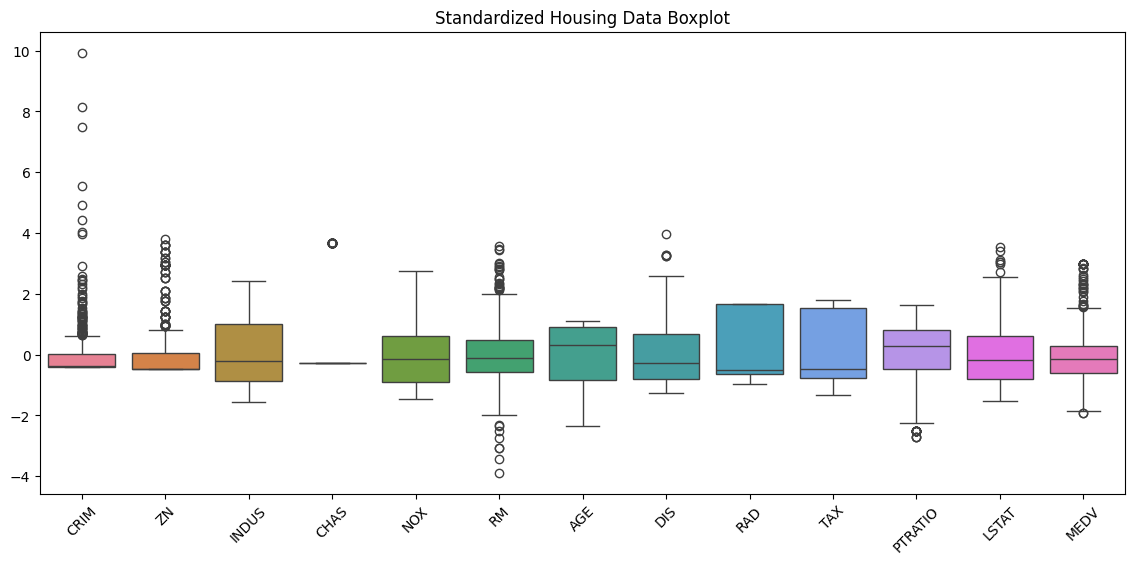

In [298]:
# ============================================================
# 7. 정규화된 데이터 분포 확인 - 상자 그림
# ============================================================

# 상자 그림은 각 컬럼의 데이터 분포와 이상치를 확인할 때 사용합니다.
# 표준화가 잘 되었다면 대부분의 컬럼이 평균 0 근처를 중심으로 비슷한 스케일을 갖습니다.
plt.figure(figsize=(14, 6))
sns.boxplot(data=Z_data)
plt.title('Standardized Housing Data Boxplot')
plt.xticks(rotation=45)
plt.show()


In [299]:
# ============================================================
# 8. pandas/numpy 데이터를 PyTorch Tensor로 변환
# ============================================================

# PyTorch 모델은 pandas DataFrame을 직접 입력받지 않습니다.
# 따라서 numpy 배열로 바꾼 뒤 torch.tensor로 변환해야 합니다.

# 입력 데이터는 실수형 연산을 위해 float32 타입으로 변환합니다.
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

# 정답 데이터도 float32로 변환합니다.
# 회귀 문제에서는 정답도 실수형 값입니다.
# view(-1, 1)은 shape을 [샘플수]에서 [샘플수, 1] 형태로 바꿉니다.
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print('X_train_tensor 모양:', X_train_tensor.shape)
print('y_train_tensor 모양:', y_train_tensor.shape)
print('X_test_tensor 모양:', X_test_tensor.shape)
print('y_test_tensor 모양:', y_test_tensor.shape)

# TensorDataset은 입력 Tensor와 정답 Tensor를 한 쌍으로 묶어줍니다.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# DataLoader는 Dataset에서 데이터를 batch_size만큼 잘라서 반복적으로 꺼내줍니다.
# shuffle=True는 매 epoch마다 데이터 순서를 섞어 과적합을 줄이고 학습 안정성을 높입니다.
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print('학습 배치 개수:', len(train_loader))


X_train_tensor 모양: torch.Size([354, 12])
y_train_tensor 모양: torch.Size([354, 1])
X_test_tensor 모양: torch.Size([152, 12])
y_test_tensor 모양: torch.Size([152, 1])
학습 배치 개수: 6


In [300]:
# ============================================================
# 9. PyTorch DNN 모델 정의
# ============================================================

# nn.Module은 PyTorch에서 신경망 모델을 만들 때 상속해야 하는 기본 클래스입니다.
class HousingDNN(nn.Module):
    def __init__(self, input_dim):
        # 부모 클래스인 nn.Module의 초기화 함수를 호출합니다.
        super(HousingDNN, self).__init__()

        # 원본 Keras 모델 구조:
        # Dense(200, activation='relu')
        # Dense(1000, activation='relu')
        # Dense(1)
        #
        # PyTorch에서는 nn.Linear가 Keras의 Dense와 같은 역할을 합니다.
        self.net = nn.Sequential(
            # 첫 번째 완전연결층입니다.
            # input_dim개의 입력 변수를 받아 200개의 뉴런으로 변환합니다.
            nn.Linear(input_dim, 200),

            # ReLU는 음수는 0으로 만들고 양수는 그대로 통과시키는 활성화 함수입니다.
            # 딥러닝에서 비선형 관계를 학습하기 위해 사용합니다.
            nn.ReLU(),

            # 두 번째 완전연결층입니다.
            # 200개의 값을 받아 1000개의 뉴런으로 확장합니다.
            nn.Linear(200, 1000),

            # 두 번째 은닉층 뒤에도 ReLU를 적용합니다.
            nn.ReLU(),

            # 출력층입니다.
            # 주택 가격 하나를 예측해야 하므로 출력 뉴런은 1개입니다.
            # 회귀 문제에서는 마지막에 sigmoid나 softmax를 사용하지 않습니다.
            nn.Linear(1000, 1)
        )

    def forward(self, x):
        # forward 함수는 모델에 입력값 x가 들어왔을 때 어떤 계산을 할지 정의합니다.
        # nn.Sequential에 정의된 계층을 순서대로 통과시킨 결과를 반환합니다.
        return self.net(x)

# 입력 변수 개수는 X_train의 컬럼 수입니다.
input_dim = X_train.shape[1]

# 모델 객체를 생성한 후 GPU 또는 CPU 장치로 이동합니다.
model = HousingDNN(input_dim).to(device)

print(model)

# 모델의 전체 학습 파라미터 수를 계산합니다.
# 파라미터는 학습 과정에서 값이 바뀌는 가중치와 편향을 의미합니다.
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('학습 가능한 파라미터 수:', total_params)


HousingDNN(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=1000, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1000, out_features=1, bias=True)
  )
)
학습 가능한 파라미터 수: 204601


In [301]:
# ============================================================
# 10. 손실 함수와 최적화 함수 설정
# ============================================================

# MSELoss는 평균 제곱 오차입니다.
# 실제값과 예측값의 차이를 제곱한 뒤 평균을 구합니다.
# 회귀 문제에서 가장 기본적으로 사용하는 손실 함수입니다.
criterion = nn.MSELoss()

# SGD는 확률적 경사하강법입니다.
# 손실을 줄이는 방향으로 모델의 가중치를 조금씩 수정합니다.
# 원본 Keras 코드의 optimizer='sgd'와 같은 역할을 합니다.
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)

print('손실 함수:', criterion)
print('최적화 함수:', optimizer)


손실 함수: MSELoss()
최적화 함수: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [302]:
# ============================================================
# 11. DNN 모델 학습
# ============================================================

print('DNN 딥러닝 학습 시작')
begin = time()

# epoch별 평균 손실값을 저장할 리스트입니다.
# 학습 후 손실값 변화 그래프를 그리는 데 사용합니다.
train_losses = []

# EPOCHS만큼 전체 학습 데이터를 반복 학습합니다.
for epoch in range(1, EPOCHS + 1):
    # model.train()은 모델을 학습 모드로 전환합니다.
    # Dropout, BatchNorm 같은 계층이 있을 때 학습/평가 동작이 달라지므로 습관적으로 사용합니다.
    model.train()

    # 한 epoch 동안의 누적 손실값입니다.
    running_loss = 0.0

    # train_loader에서 batch 단위로 데이터를 꺼냅니다.
    for batch_X, batch_y in train_loader:
        # 입력과 정답 Tensor를 GPU 또는 CPU 장치로 이동합니다.
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # 이전 batch에서 계산된 기울기가 남아 있지 않도록 초기화합니다.
        # PyTorch는 기본적으로 gradient를 누적하기 때문에 매번 zero_grad가 필요합니다.
        optimizer.zero_grad()

        # 순전파: 입력 데이터를 모델에 넣어 예측값을 계산합니다.
        outputs = model(batch_X)

        # 손실 계산: 예측값과 실제값 사이의 MSE를 계산합니다.
        loss = criterion(outputs, batch_y)

        # 역전파: 손실값을 기준으로 각 파라미터의 기울기를 계산합니다.
        loss.backward()

        # 가중치 업데이트: 계산된 기울기를 이용해 모델 파라미터를 수정합니다.
        optimizer.step()

        # 현재 batch의 손실값에 batch 데이터 수를 곱해 누적합니다.
        running_loss += loss.item() * batch_X.size(0)

    # epoch 전체 평균 손실값을 계산합니다.
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # 학습 진행 상황을 50 epoch마다 출력합니다.
    # 첫 번째 epoch도 확인할 수 있도록 조건에 포함합니다.
    if epoch == 1 or epoch % 50 == 0:
        print(f'Epoch [{epoch:4d}/{EPOCHS}] - Train MSE Loss: {epoch_loss:.6f}')

end = time()
print(f'총 딥러닝 학습 시간: {end - begin:.1f}초')


DNN 딥러닝 학습 시작
Epoch [   1/500] - Train MSE Loss: 0.816871
Epoch [  50/500] - Train MSE Loss: 0.221599
Epoch [ 100/500] - Train MSE Loss: 0.175217
Epoch [ 150/500] - Train MSE Loss: 0.151048
Epoch [ 200/500] - Train MSE Loss: 0.132377
Epoch [ 250/500] - Train MSE Loss: 0.119886
Epoch [ 300/500] - Train MSE Loss: 0.109851
Epoch [ 350/500] - Train MSE Loss: 0.103088
Epoch [ 400/500] - Train MSE Loss: 0.095100
Epoch [ 450/500] - Train MSE Loss: 0.089099
Epoch [ 500/500] - Train MSE Loss: 0.080716
총 딥러닝 학습 시간: 11.0초


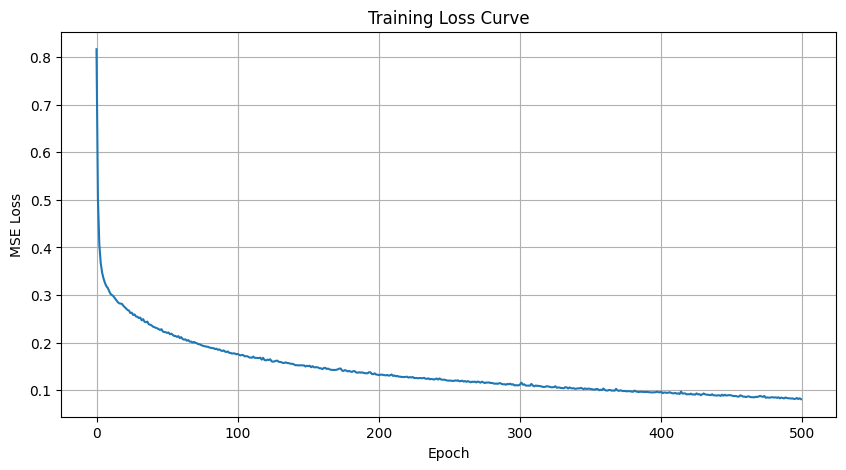

In [303]:
# ============================================================
# 12. 학습 손실값 변화 시각화
# ============================================================

# 손실값이 epoch가 증가할수록 대체로 감소하면 모델이 학습되고 있다는 의미입니다.
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()


In [304]:
# ============================================================
# 13. 테스트 데이터 평가
# ============================================================

# model.eval()은 모델을 평가 모드로 전환합니다.
model.eval()

# torch.no_grad()는 평가 단계에서 기울기를 계산하지 않도록 합니다.
# 평가에서는 가중치 업데이트가 필요 없으므로 메모리 사용량과 계산 시간을 줄일 수 있습니다.
with torch.no_grad():
    # 테스트 입력 데이터를 장치로 이동합니다.
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)

    # 테스트 데이터에 대한 예측값을 계산합니다.
    test_pred_tensor = model(X_test_device)

    # PyTorch 기준 테스트 MSE를 계산합니다.
    test_loss = criterion(test_pred_tensor, y_test_device).item()

print(f'DNN 테스트 평균 제곱 오차(MSE): {test_loss:.6f}')

# sklearn 평가 지표 계산을 위해 Tensor를 CPU의 numpy 배열로 변환합니다.
y_test_np = y_test_tensor.numpy()
pred_np = test_pred_tensor.cpu().numpy()

# RMSE는 MSE의 제곱근입니다.
# 원래 값의 단위와 비슷하게 해석할 수 있어 회귀 모델 평가에서 자주 사용합니다.
rmse = np.sqrt(mean_squared_error(y_test_np, pred_np))

# R² Score는 모델이 정답의 변동성을 얼마나 설명하는지 보여주는 지표입니다.
# 1에 가까울수록 좋고, 0에 가까우면 평균값 예측과 비슷하다는 뜻입니다.
r2 = r2_score(y_test_np, pred_np)

print(f'RMSE: {rmse:.6f}')
print(f'R² Score: {r2:.6f}')


DNN 테스트 평균 제곱 오차(MSE): 0.185975
RMSE: 0.431248
R² Score: 0.827919


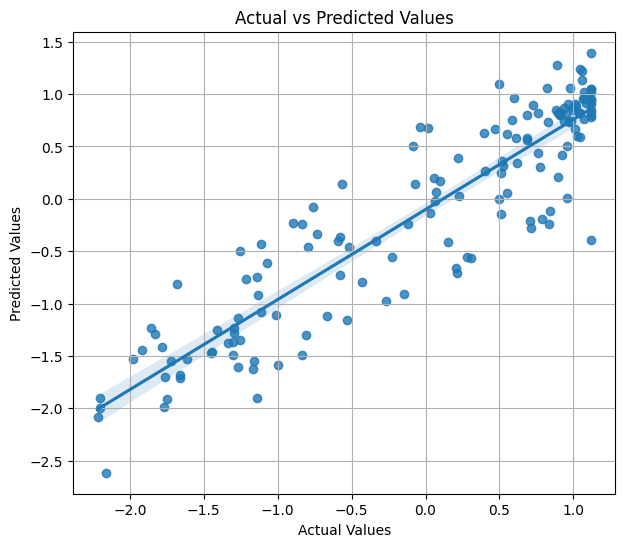

In [305]:
# ============================================================
# 14. 실제값과 예측값 비교 산포도
# ============================================================

# 실제값과 예측값이 비슷할수록 점들이 대각선 방향에 가깝게 분포합니다.
plt.figure(figsize=(7, 6))
sns.regplot(x=y_test_np.flatten(), y=pred_np.flatten())
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.grid(True)
plt.show()


In [306]:
# ============================================================
# 15. 예측 결과 일부 확인
# ============================================================

# 실제값과 예측값을 하나의 표로 묶어서 비교합니다.
# 현재 값들은 MEDV까지 표준화된 값이므로 원래 가격 단위가 아니라 Z-score 기준 값입니다.
result_df = pd.DataFrame({
    'Actual_MEDV_Zscore': y_test_np.flatten(),
    'Predicted_MEDV_Zscore': pred_np.flatten(),
    'Error': y_test_np.flatten() - pred_np.flatten()
})

print('예측 결과 샘플 10개')
display(result_df.head(10))


예측 결과 샘플 10개


,Actual_MEDV_Zscore,Predicted_MEDV_Zscore,Error
0,0.552081,0.622810,-0.070728
1,-1.268620,-1.137958,-0.130662
2,1.074822,1.015252,0.059569
3,-2.161190,-2.614583,0.453393
4,0.825898,0.734555,0.091343
5,0.210700,-0.711102,0.921802
6,0.520077,0.356002,0.164075
7,0.889907,1.272715,-0.382809
8,0.786781,-0.188392,0.975173
9,0.395615,0.629736,-0.234121


In [307]:
# ============================================================
# 16. 원래 MEDV 단위로 예측값 복원하기
# ============================================================

# 이 노트북은 원본 코드와 동일하게 MEDV까지 포함한 전체 데이터를 StandardScaler로 표준화했습니다.
# 따라서 모델 예측 결과도 표준화된 MEDV 값입니다.
# 수업에서는 원래 주택 가격 단위로 해석하는 방법도 함께 확인하는 것이 좋습니다.

# scaler.mean_과 scaler.scale_에는 각 컬럼의 평균과 표준편차가 저장되어 있습니다.
# MEDV 컬럼의 위치를 찾습니다.
medv_index = list(raw.columns).index('MEDV')
medv_mean = scaler.mean_[medv_index]
medv_std = scaler.scale_[medv_index]

# Z-score를 원래 값으로 복원하는 공식은 다음과 같습니다.
# 원래값 = Z값 * 표준편차 + 평균
actual_medv_original = y_test_np.flatten() * medv_std + medv_mean
pred_medv_original = pred_np.flatten() * medv_std + medv_mean

original_result_df = pd.DataFrame({
    'Actual_MEDV_Original': actual_medv_original,
    'Predicted_MEDV_Original': pred_medv_original,
    'Error_Original': actual_medv_original - pred_medv_original
})

print('원래 MEDV 단위로 복원한 예측 결과 샘플 10개')
display(original_result_df.head(10))

# 원래 단위 기준의 MSE, RMSE, R²를 계산합니다.
original_mse = mean_squared_error(actual_medv_original, pred_medv_original)
original_rmse = np.sqrt(original_mse)
original_r2 = r2_score(actual_medv_original, pred_medv_original)

print(f'원래 단위 기준 MSE: {original_mse:.6f}')
print(f'원래 단위 기준 RMSE: {original_rmse:.6f}')
print(f'원래 단위 기준 R² Score: {original_r2:.6f}')


원래 MEDV 단위로 복원한 예측 결과 샘플 10개


,Actual_MEDV_Original,Predicted_MEDV_Original,Error_Original
0,27.605337,28.255187,-0.649851
1,10.876712,12.077239,-1.200527
2,32.408282,31.860957,0.547325
3,2.675765,-1.490013,4.165778
4,30.121165,29.281903,0.839262
5,24.468719,15.999190,8.469529
6,27.311279,25.803760,1.507519
7,30.709280,34.226529,-3.517249
8,29.761761,20.801862,8.959899
9,26.167720,28.318826,-2.151106


원래 단위 기준 MSE: 15.699900
원래 단위 기준 RMSE: 3.962310
원래 단위 기준 R² Score: 0.827919


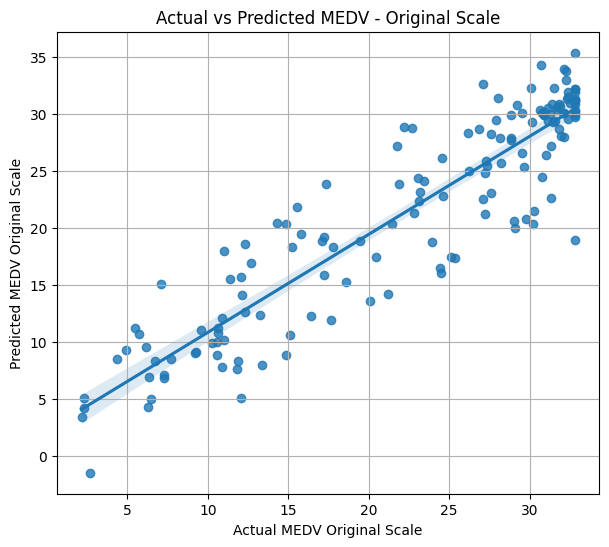

In [308]:
# ============================================================
# 17. 원래 단위 기준 실제값과 예측값 비교 그래프
# ============================================================

plt.figure(figsize=(7, 6))
sns.regplot(x=actual_medv_original, y=pred_medv_original)
plt.xlabel('Actual MEDV Original Scale')
plt.ylabel('Predicted MEDV Original Scale')
plt.title('Actual vs Predicted MEDV - Original Scale')
plt.grid(True)
plt.show()
